In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, parameters_setup, propagation_setup
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, estimation_analysis
from tudatpy.constants import GRAVITATIONAL_CONSTANT
from tudatpy.astro.frame_conversion import inertial_to_rsw_rotation_matrix
import matplotlib.gridspec as gridspec
from tudatpy.data.mpc import BatchMPC
from tudatpy.data.horizons import HorizonsQuery
from tudatpy.data.sbdb import SBDBquery
from tudatpy.estimation import observable_models, observations_setup, observations
from tudatpy import dynamics ## needed to get additional parameters to fit

# other useful modules
import numpy as np
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from tudatpy.astro import time_representation
from tudatpy.astro.time_representation import DateTime
from astropy.table import Table
from tudatpy.astro import element_conversion    # for TU3 initial state

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates

# SPICE KERNELS
spice.load_standard_kernels()

# Defining some constants

In [ ]:
# Target 1998 TU3 (66146)
target_mpc_code = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
# target_mpc_code = [1566, 66146, 66391, 437844, 138127]
# Do NOT run: 5: 137924, 
# target_mpc_code = [1566, 66146, 66391, 437844, 138127, 480883, 468468, 364136]
# target_mpc_code = [137924]

# I sat the code to 1982 and then it ran for 2 hours (and wasn't showing any signs of stopping)
# But at 1985 it all works within a few minutes
observations_start = datetime.datetime(1985, 1, 1)
observations_end = datetime.datetime(2026, 1, 1)

# number of iterations for our estimation
# Change this depending on how long you want the convergence to run
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 2 month time buffer used to avoid interpolation errors:
time_buffer = 2 * 31 * 86400.0

# Define the frame origin and orientation
# This is useful for the large functions at the end
# However, I still define the frame orientation before then for my bodies
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

include_minor_bodies = True

In [260]:
#target_sbdb = SBDBquery(target_mpc_code)
#
#mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
#target_spkid = target_sbdb.codes_300_spkid  # the ID used by Tudat
#obj = target_sbdb.query["object"]
#
## The ID used by Tudat (biggest asteroids have shortname, but smaller don't)
#target_name = (
#    obj.get("shortname") or
#    obj.get("fullname") or
#    obj.get("des")
#)  
#
#print(f"SPK ID for {target_name} is: {target_spkid}")

# Retrieving the observations

In [261]:

mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)
print(batch.summary())

## Make sure wrapping is not an issue
batch.table["RA"] = (batch.table["RA"] + np.pi) % (2*np.pi) - np.pi


   Batch Summary:
1. Batch includes 3 minor planets:
   ['66146', '66391', '437844']
2. Batch includes 6390 observations, including 130 observations from space telescopes
3. The observations range from 10008348.153540073 to 806067999.9996754
   In seconds TDB since J2000: 10008348.153540073 to 806067999.9996754
   In Julian Days: 2451660.83662 to 2460874.48994
4. The batch contains observations from 202 observatories, including 1 space telescopes

None


In [262]:
epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")


# This samples the cartesian state at 500 points over the observation time:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print(f"Epoch Start (buffer): {DateTime.from_epoch(epoch_start_buffer)}")
print(f"Epoch End (buffer): {DateTime.from_epoch(epoch_end_buffer)}")
print()
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Epoch Start (no buffer): 10008348.153540073
Epoch End (no buffer): 806067999.9996754
--------------------------------------------------
Epoch Start (no buffer): 2000-04-26 08:05:48.153540072962642
Epoch End (no buffer): 2025-07-17 23:46:39.999675393104553
--------------------------------------------------
Epoch Start (buffer): 2000-02-24 08:05:48.153540072962642
Epoch End (buffer): 2025-09-17 23:46:39.999675393104553

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE  130.0


# Set up the environment

In [263]:
# larger_bodies_to_create = [
#     "Sun",
#     "Mercury",
#     "Venus",
#     "Earth",
#     "Moon", ## DIFF
#     "Mars",
#     "Jupiter",
#     "Saturn",
#     "Uranus",
#     "Neptune",
# ]

larger_bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Phobos",   # Mars
    "Deimos",   # Mars
    "Ceres",
    "Vesta",
    "Jupiter",
    "Io",       # Jupiter
    "Europa",   # Jupiter
    "Ganymede", # Jupiter
    "Callisto", # Jupiter
    "Saturn",
    "Titan",    # Saturn
    "Rhea",     # Saturn
    "Iapetus",  # Saturn
    "Dione",    # Saturn
    "Tethys",
    "Enceladus",
    "Mimas",
    "Uranus",
    "Neptune",
]

if include_minor_bodies:
    ## Ignore this for now
    smaller_bodies = {
        # "Ceres": [1, 62.10], 
        "Pallas": [2, 13.73],
        "Juno": [3, 1.61],
        # "Vesta": [4, 17.38],
        "Hebe": [6, 0.89],
        "Iris": [7, 0.73],
        "Flora": [8, 0.27],
        "Metis": [9, 0.44],
        "Hygiea": [10, 5.97],
        "Irene": [14, 0.25],
        "Eunomia": [15, 1.88],
        "Psyche": [16, 1.65],
        "Fortuna": [19, 0.42],
        "Thalia": [23, 0.15],
        "Amphitrite": [29, 0.98],
        "Daphne": [41, 0.56],
        "Europa": [52, 1.48],
        "Bamberga": [324, 0.71],
        "Davida": [511, 1.14],
        "Herculina": [532, 0.66],
        "Interamnia": [704, 2.65]
    }

In [264]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
#kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 
kernel_directory = "/home/balbinot/Bachelor_Project_Emma/asteroid_kernels/" 
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

if include_minor_bodies:
    # Loop through the dictionary and load the corresponding .bsp file
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
        
        # Calculate the NAIF ID from the data list
        # E.g. Juno has 20000003 (ID: 3)
        ast_id = data[0]
        naif_id = 20000000 + ast_id
        
        # Then extract the ephemeris for each asteroid
        kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
        if os.path.exists(kernel_path):
            spice.load_kernel(kernel_path)
            print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
        else:
            print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

Number of kernels: 13


In [265]:
asteroid_id_list = [str(i_ast) for i_ast in target_mpc_code]

smaller_bodies_list = []
if include_minor_bodies:
    smaller_bodies_list = list(smaller_bodies.keys())

bodies_to_create = larger_bodies_to_create + smaller_bodies_list + asteroid_id_list
bodies_to_propagate = asteroid_id_list     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.
# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Add a buffer time
buffer_time = 5 * constants.JULIAN_DAY

if include_minor_bodies:
    # A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
        # Extract asteroid properties
        ast_id = data[0]
        ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units); reduced mass
    
        # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
        naif_id = 20000000 + ast_id
    
        try:
            
            # To fix Tudat finding the data:
            naif_id_str = str(2000000 + ast_id)
    
            # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
            DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
                frame_origin = 'SSB',                    # The SPK files were w.r.t the Sun
                frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
                body_name_to_use = naif_id_str)
    
            # Create empty slots, then insert the asteroids
            body_settings.add_empty_settings(name)
            # Assign ephemeris
            body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast
    
            # Assign gravity field (w. the central function that manually adds the mu)
            body_settings.get(name).gravity_field_settings = (
                environment_setup.gravity_field.central(ast_mu)
            )
    
            print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")
    
        except Exception as e:
            print(f"Could not fetch data for {name}: {e}")


## NOTE EB: I removed this without any impact on the rest of the code
## NOTE: body_settings does not include the members in target_mpc_list
# Manually add empty settings for 9 asteroids
#for name in asteroid_id_list:
#    body_settings.add_empty_settings(name)


In [266]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic
# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6         # ± 0.07 * 10**6 m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

bodies = environment_setup.create_system_of_bodies(body_settings) ## Define this here too since observations need it?
bodies_to_propagate = batch.MPC_objects
central_bodies = ["SSB"] * len(batch.MPC_objects)

In [267]:
# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None,
                                        apply_star_catalog_debias=True, apply_weights_VFCC17=True,)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

/home/emmabob/Bachelor_Project/tudat-dev/.pixi/envs/default/lib/python3.14/site-packages/tudatpy/data/mpc/mpc.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bias_dataframe[["aa", "bb", "cc", "dd"]] = unknown_columns
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function s

In [268]:
initial_guess_list = []

for i_horizon in asteroid_id_list:
    print(i_horizon)
    obj = HorizonsQuery(
        query_id=i_horizon,
        location="@0",
        epoch_list=[epoch_start_buffer],
    )

    initial_guess = obj.cartesian(frame_orientation='J2000',
                aberations='geometric')

    initial_guess = initial_guess[0][1:]    # unpack and remvoe the first component (that is time)
    initial_guess_list.append(initial_guess)

# To make the initial guess into (N*6,) instead of (N, 6) (where N is the amount of asteroid estimated for)
# This makes the initial guess into one long array
initial_guess = np.concatenate(initial_guess_list)


66146
66391
437844


In [269]:
# initial_guess - initial_guess_spice

In [270]:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print("The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):")
print(epoch_start_buffer, initial_guess)

The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):
4651548.153540073 [ 1.57390134e+11 -3.25651669e+10 -2.91470084e+10  1.17197144e+04
  1.77396463e+04  6.09596002e+03  3.87860688e+10 -2.00541743e+10
  2.58897313e+10 -1.32105235e+04  5.98483485e+04 -4.38558461e+03
  6.78041802e+10 -1.00684289e+11 -4.69275761e+10  8.93038839e+03
  2.33008378e+04  9.90362211e+03]


In [271]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
print(A_2_TU3_ms2)

The Yarkovksy parameter for TU3: -5.14011492352202e-13 AU / days^2
3.579722893167121e-13
-1.030079528444796e-11


In [272]:
# The Yarkovksy Parameters for 8 out of 9 asteroids
# They were calculated in the file Table_of_Asteroids/test_Table_Code.ipynb
# The 6th asteroid, (138127) 2000 EE14 does not have a value in literature and is therefore set to zero
# However, it does have an uncertainty

A_2_ast_ms2 = np.array([-7.4947047935106e-14, -1.79655733799732e-13, -1.1402599897661214e-13, 8.080665194434216e-13, -2.3011625098947506e-13, 0.0, -1.3698663069299618e-12, -1.3118190748109315e-12, -6.383317087378818e-13])

In [273]:
# # # The planets
# # acceleration_planets_LVL3 = {
# #     "Sun": [
# #         #propagation_setup.acceleration.point_mass_gravity(),
# #         propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
# #         propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
# #         #propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2), 
# #     ],
# #     "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Venus": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Earth": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Moon": [propagation_setup.acceleration.point_mass_gravity()], ## THE FREEKING MOON
# #     "Mars": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
# #     "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
# # }


# # LVL 3 from Tudat example
# acceleration_planets_LVL3 = {
#     "Sun": [
#         # propagation_setup.acceleration.point_mass_gravity(),
#         propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
#         propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
#         propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2), 
#     ],
#     "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
#     "Venus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Earth": [
#         propagation_setup.acceleration.spherical_harmonic_gravity(2, 2),
#     ],
#     "Moon": [propagation_setup.acceleration.point_mass_gravity()],

#     "Mars": [propagation_setup.acceleration.point_mass_gravity()],
#     "Phobos": [propagation_setup.acceleration.point_mass_gravity()],
#     "Deimos": [propagation_setup.acceleration.point_mass_gravity()],

#     "Ceres": [propagation_setup.acceleration.point_mass_gravity()],
#     "Vesta": [propagation_setup.acceleration.point_mass_gravity()],
#     "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
#     "Io": [propagation_setup.acceleration.point_mass_gravity()],
#     "Europa": [propagation_setup.acceleration.point_mass_gravity()],
#     "Ganymede": [propagation_setup.acceleration.point_mass_gravity()],
#     "Callisto": [propagation_setup.acceleration.point_mass_gravity()],

#     "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
#     "Titan": [propagation_setup.acceleration.point_mass_gravity()],
#     "Rhea": [propagation_setup.acceleration.point_mass_gravity()],
#     "Iapetus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Dione": [propagation_setup.acceleration.point_mass_gravity()],
#     "Tethys": [propagation_setup.acceleration.point_mass_gravity()],
#     "Enceladus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Mimas": [propagation_setup.acceleration.point_mass_gravity()],
#     "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
# }


# if include_minor_bodies:
#     accelerations_asteroids = {
        
#         asteroid_name_21_index: [
#             propagation_setup.acceleration.point_mass_gravity()
#         ]
#         for asteroid_name_21_index in smaller_bodies_list
#     }
    
    
#     # Merge dictionaries
#     accelerations_merged_LVL3 = (
#         acceleration_planets_LVL3 |
#         accelerations_asteroids
#     )
    
# else:
#     accelerations_merged_LVL3 = acceleration_planets_LVL3
    

# # For testing remove asteroids since estimar runs much faster like this
# #accelerations_merged_LVL3 = acceleration_planets_LVL3

# # Finally, define the acceleration for TU3
# # Because only TU3 is propagated
# acceleration_dict3 = {b: accelerations_merged_LVL3 for b in bodies_to_propagate}


In [274]:
acceleration_dict3_insideloop = {}

for asteroid_name, A2_ast in zip(target_mpc_code, A_2_ast_ms2):

    accelerations_LVL3 = {

        "Sun": [
            propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
            propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
            propagation_setup.acceleration.yarkovsky(A2_ast),
        ],

        "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
        "Venus": [propagation_setup.acceleration.point_mass_gravity()],
        "Earth": [propagation_setup.acceleration.spherical_harmonic_gravity(2, 2)],
        "Moon": [propagation_setup.acceleration.point_mass_gravity()],
        "Mars": [propagation_setup.acceleration.point_mass_gravity()],
        "Phobos": [propagation_setup.acceleration.point_mass_gravity()],
        "Deimos": [propagation_setup.acceleration.point_mass_gravity()],

        "Ceres": [propagation_setup.acceleration.point_mass_gravity()],
        "Vesta": [propagation_setup.acceleration.point_mass_gravity()],

        "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
        "Io": [propagation_setup.acceleration.point_mass_gravity()],
        "Europa": [propagation_setup.acceleration.point_mass_gravity()],
        "Ganymede": [propagation_setup.acceleration.point_mass_gravity()],
        "Callisto": [propagation_setup.acceleration.point_mass_gravity()],

        "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
        "Titan": [propagation_setup.acceleration.point_mass_gravity()],
        "Rhea": [propagation_setup.acceleration.point_mass_gravity()],
        "Iapetus": [propagation_setup.acceleration.point_mass_gravity()],
        "Dione": [propagation_setup.acceleration.point_mass_gravity()],
        "Tethys": [propagation_setup.acceleration.point_mass_gravity()],
        "Enceladus": [propagation_setup.acceleration.point_mass_gravity()],
        "Mimas": [propagation_setup.acceleration.point_mass_gravity()],

        "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
        "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
    }

    # if include_minor_bodies:
    #     accelerations_asteroids = {
            
    #         asteroid_name_21_index: [
    #             propagation_setup.acceleration.point_mass_gravity()
    #         ]
    #         for asteroid_name_21_index in smaller_bodies_list
    #     }
        
        
    #     # Merge dictionaries
    #     acceleration_dict3_ast = (
    #         accelerations_LVL3 |
    #         accelerations_asteroids
    #     )
        
    # else:
    #     acceleration_dict3_ast = accelerations_LVL3

    if include_minor_bodies:

        accelerations_LVL3.update({
            perturber: [
                propagation_setup.acceleration.point_mass_gravity()
            ]
            for perturber in smaller_bodies_list
        })

    acceleration_dict3_insideloop[str(asteroid_name)] = accelerations_LVL3

# # Finally, define the acceleration for TU3
# # Because only TU3 is propagated
# acceleration_dict3 = {b: accelerations_merged_LVL3 for b in bodies_to_propagate}
acceleration_dict3 = acceleration_dict3_insideloop

In [275]:
acceleration_dict3

{'66146': {'Sun': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x70ebfcabf930>,
  'Mercury': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ebff0c3a30>],
  'Venus': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ebff0c1ff0>],
  'Earth': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x70ebff0c03f0>],
  'Moon': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ebff0c28f0>],
  'Mars': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ec47f69bb0>],
  'Phobos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ec057e1bb0>],
  'Deimos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x70ec041ce970>],
  'Ceres': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.Accelerati

In [276]:
# Thus, the environment becomes:
# In other of my files this is body_system
# However to be compatible with Tudat example, here it's called bodies
#bodies = environment_setup.create_system_of_bodies(body_settings)

In [277]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

In [278]:
# Create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_dict3, bodies_to_propagate, central_bodies
)

In [279]:
print(central_bodies, acceleration_models, bodies_to_propagate)

['SSB', 'SSB', 'SSB'] {'66146': {'Vesta': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabe970>], 'Titan': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabdb30>], 'Rhea': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabe0f0>], 'Phobos': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabe630>], 'Neptune': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabca30>], 'Moon': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabd1f0>], 'Venus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabd030>], 'Mimas': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabce70>], 'Callisto': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabdfb0>], 'Earth': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x70ebfcabd0b0>], 'Enceladus': [<tudatpy.kernel.dyn

In [280]:
# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies=central_bodies,
    acceleration_models=acceleration_models,
    bodies_to_integrate=bodies_to_propagate,
    initial_states=initial_guess,
    initial_time=epoch_start_buffer,
    integrator_settings=integrator_settings,
    termination_settings=termination_condition,
)

In [281]:
# Initial state
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# The Yarkovsky Effect for all 9 asteroids
for i, ID in enumerate(target_mpc_code):
    # if ID = 
    parameter_settings.append(dynamics.parameters_setup.yarkovsky_parameter(f"{target_mpc_code[i]}"))

## J2 and Beta
parameter_settings.append(dynamics.parameters_setup.spherical_harmonics_c_coefficients_block("Sun", [(2,0)])) ##Indicate the indices of the free parameters in your C matrix for SPERICAL HARMONICS
parameter_settings.append(dynamics.parameters_setup.ppn_parameter_beta())

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function


In [282]:
# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times = observation_collection,
    convergence_checker = estimation_analysis.estimation_convergence_checker(
        maximum_iterations = number_of_pod_iterations,
    ),
)

# to_tudat() applies weights to a set of observations between an observatory and the target.
# the method below tells tudat to use the weights applied to these sets.
# This step is required when setting weights through the BatchMPC class.
if True:
    pod_input.set_weights_from_observation_collection()
    
# Set methodological options
print("Creating pod_input", flush=True)
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

# Perform the estimation
print("Creating pod_output", flush=True)
pod_output = estimator.perform_estimation(pod_input)


# we store the following outputs for plotting and analysis.
#return pod_output, batch_temp, observations, estimator

Creating pod_input
Creating pod_output


setWeightsFromObservationCollection is deprecated: the weightsMatrixDiagonals_ vector is now by default defined by the weights stored in the ObservationCollection object. (see https://docs.tudat.space/en/latest/user-guide/state-estimation/observation-simulation/observation-collection-manipulation/modifying-collections.html#setting-weights).


Calculating residuals and partials 12520
Current residual: 0.000350128
Parameter update     57358.2     -8943.82      30297.4  -0.00936515  -0.00143519   -0.0014625        19405      47975.8     -31987.9   -0.0354253    0.0208978  -0.00596545      23074.9      9190.08      7310.45  -0.00158168   0.00263612   0.00312249 -4.94811e-14  4.05689e-13  9.51434e-13   -0.0382797  1.16089e-06
Calculating residuals and partials 12520
Current residual: 3.27611e-06
Parameter update     772.476     -425.015     -296.799 -0.000289862 -5.48937e-05   2.3631e-05     -2168.97      23088.9     -328.032   -0.0133382    0.0053147  -0.00804116     -2588.28     -678.219     -694.849  0.000684485 -6.27275e-05 -2.98407e-05 -1.20903e-15  8.83415e-14  1.25168e-14  -0.00501413 -1.15458e-07
Calculating residuals and partials 12520
Current residual: 3.27071e-06
Parameter update    0.024306    0.0251644    0.0057005 -6.72106e-09 -5.55694e-10  4.23039e-10   -0.0397626     0.115554    0.0131595 -6.41076e-08  3.41195e-0

Warning when performing least squares, condition number is 1.37329e+09
Warning when performing least squares, condition number is 1.36967e+09
Warning when performing least squares, condition number is 1.36967e+09
Warning when performing least squares, condition number is 1.36967e+09
Warning when performing least squares, condition number is 1.36967e+09
Warning when performing least squares, condition number is 1.36967e+09


In [283]:
## Get best-fit states at the same times as ephemeris of Horizons etc
state_estimates = {}
for asteroid_id in target_mpc_code:
    state_estimates[asteroid_id] = np.array(
        [
            bodies.get(str(asteroid_id)).ephemeris.cartesian_state(timee) for timee in times_get_eph
        ]
    )

In [284]:
#residual_history.shape (2*N, number_iterations)
#residual_history format is [RA_0, Dec_0, RA_1, Dec_1, ..., RA_N, Dec_N) where N is the number of observations
residual_history = pod_output.residual_history
residual_times = np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000

In [285]:
residual_times[::2]

array([2010.42434745, 2010.42435032, 2010.42435317, ..., 2018.42693678,
       2018.4269653 , 2018.42699347], shape=(6260,))

In [286]:
RA_residual_0 = residual_history[::2, 0] ## 0th iteration
Dec_residual_0 = residual_history[1::2, 0] ## 0th iteration
RA_residual_final = residual_history[::2, -2] ## final iteration
Dec_residual_final = residual_history[1::2, -2] ## final iteration

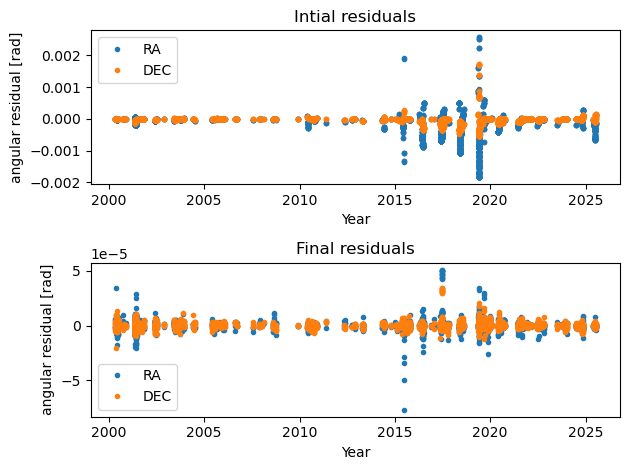

In [287]:
subplot(211)
plot(residual_times[::2], RA_residual_0, '.', label='RA')
plot(residual_times[1::2], Dec_residual_0, '.', label='DEC')
xlabel('Year')
ylabel("angular residual [rad]")
title('Intial residuals')

legend()

subplot(212)
plot(residual_times[::2], RA_residual_final, '.', label='RA')
plot(residual_times[1::2], Dec_residual_final, '.', label='DEC')
xlabel('Year')
ylabel("angular residual [rad]")
title('Final residuals')

legend()
     
tight_layout()

In [288]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[0]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

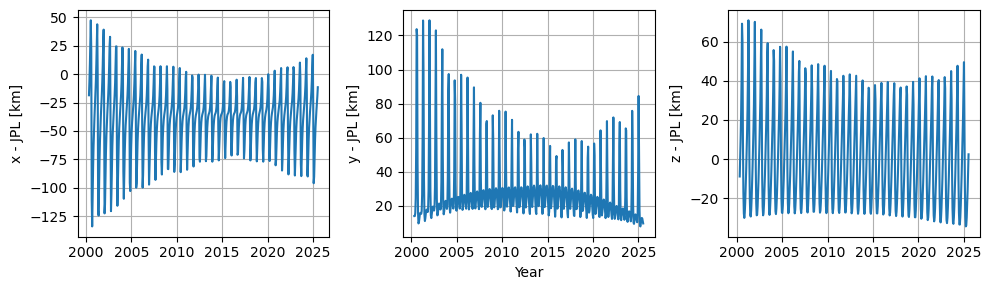

In [289]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[0]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [290]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[1]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

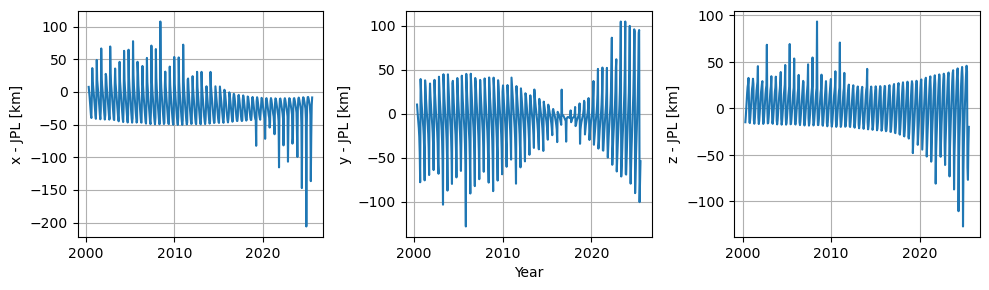

In [291]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[1]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [292]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[2]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

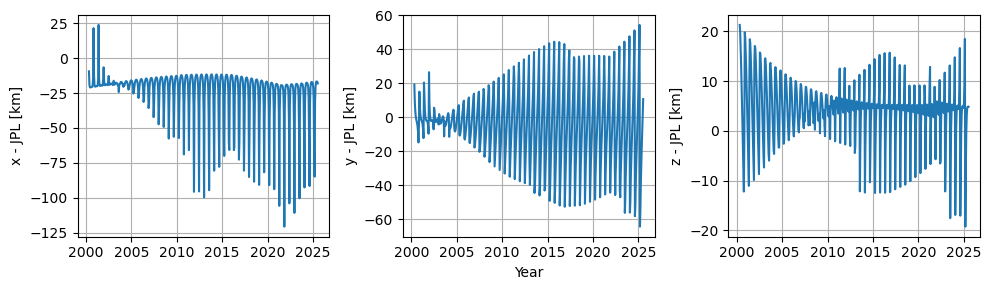

In [293]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[2]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [294]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[3]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

IndexError: list index out of range

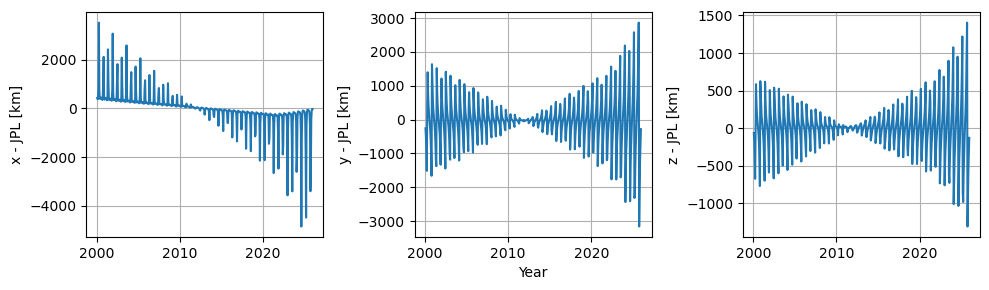

In [ ]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[3]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [ ]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[4]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

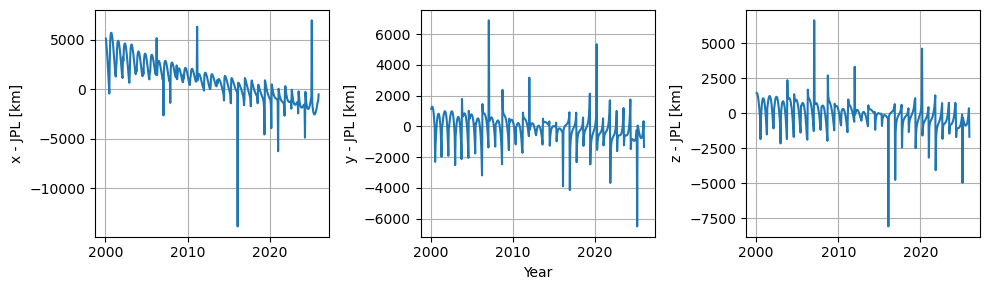

In [ ]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[4]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [ ]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[-1]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

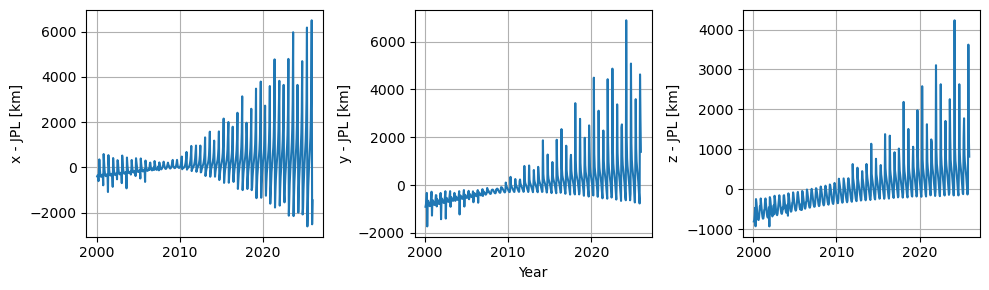

In [ ]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[-1]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [ ]:
reference_states_i = []
index_list = []

print(target_mpc_code)

for i, ast_name in enumerate(target_mpc_code):    
    print(i, ast_name)
    horizonq = HorizonsQuery(
                query_id=f"{ast_name};",
                location=f"500@{global_frame_origin}",
                epoch_list=list(times_get_eph),
                extended_query=True,
            )

    ref = horizonq.cartesian(
                frame_orientation=global_frame_orientation,
                aberations='geometric'
            )[:, 1:]
    
    index_list.append(i)
    reference_states_i.append(ref)

[1566, 66146]
0 1566
1 66146


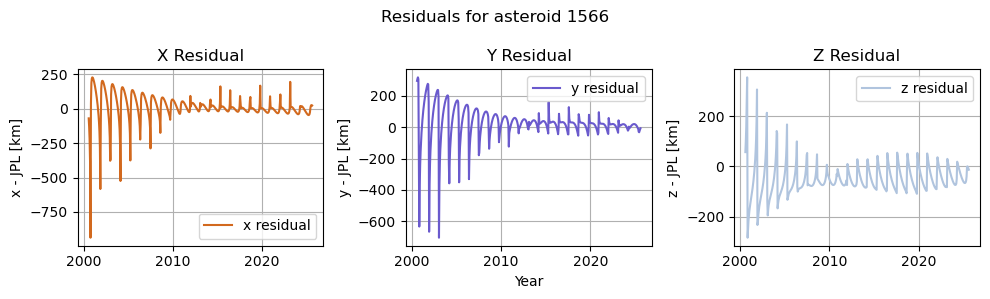

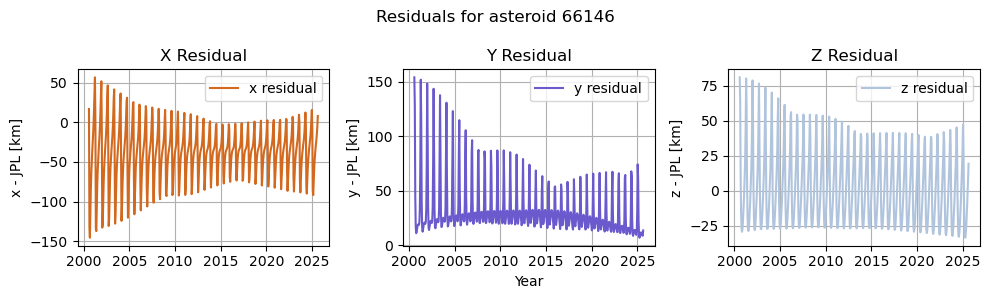

In [ ]:
for i, ref_state in zip(index_list, reference_states_i):
    # print(i, reference_states_i)
    times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

    error_to_reference_i = (reference_states_i[i] - np.array(state_estimates[target_mpc_code[i]] )) / 1000  # converting to km

    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    axs[0].plot(times_plot, error_to_reference_i[:, 0], color='chocolate', label='x residual')
    axs[0].set_title('X Residual')
    axs[0].set_ylabel('x - JPL [km]')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(times_plot, error_to_reference_i[:, 1], color='slateblue', label='y residual')
    axs[1].set_title('Y Residual')
    axs[1].set_ylabel('y - JPL [km]')
    axs[1].set_xlabel('Year')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(times_plot, error_to_reference_i[:, 2], color='lightsteelblue', label='z residual')
    axs[2].set_title('Z Residual')
    axs[2].set_ylabel('z - JPL [km]')
    axs[2].legend()
    axs[2].grid()

    fig.suptitle(f'Residuals for asteroid {target_mpc_code[i]}')

    plt.tight_layout()
    plt.show()

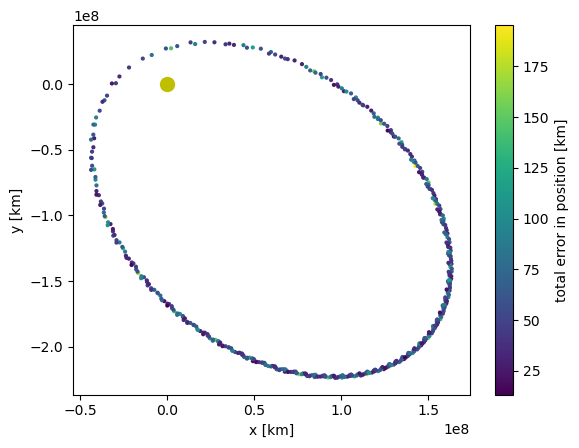

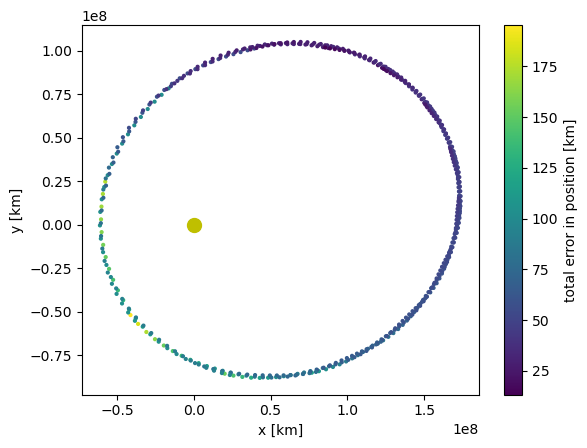

In [254]:
for i in range(2):
    ee = state_estimates[target_mpc_code[i]]

    scatter(ee[:,0]/1000, ee[:,1]/1000, c=np.linalg.norm(error_to_reference[:,], axis=1), s=4)
    cb = colorbar()
    cb.set_label('total error in position [km]')
    plot(0, 0, 'yo', ms=10)
    xlabel('x [km]')
    ylabel('y [km]')
    plt.show()


In [255]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations

Calculating residuals and partials 5620


In [256]:
# Create a function to generate the axes of the covariance matrix

def build_estimated_param_names(mpc_target_asteroid):
    base_names = ["x", "y", "z", "vx", "vy", "vz"]

    estimated_param_names = []

    # repeat state block for each asteroid
    for i, _ in enumerate(mpc_target_asteroid, start=1):
        state_block = [f"{name}_{i}" for name in base_names]
        estimated_param_names.extend(state_block)

    # add global parameters (only once)
    estimated_param_names += [f"A_2_{i}" for i in index_list]

    # add global parameters (only once)
    estimated_param_names += ["J2", "Beta-1"]

    return estimated_param_names


estimated_param_names = build_estimated_param_names(target_mpc_code)

print(estimated_param_names)

['x_1', 'y_1', 'z_1', 'vx_1', 'vy_1', 'vz_1', 'x_2', 'y_2', 'z_2', 'vx_2', 'vy_2', 'vz_2', 'A_2_0', 'A_2_1', 'J2', 'Beta-1']


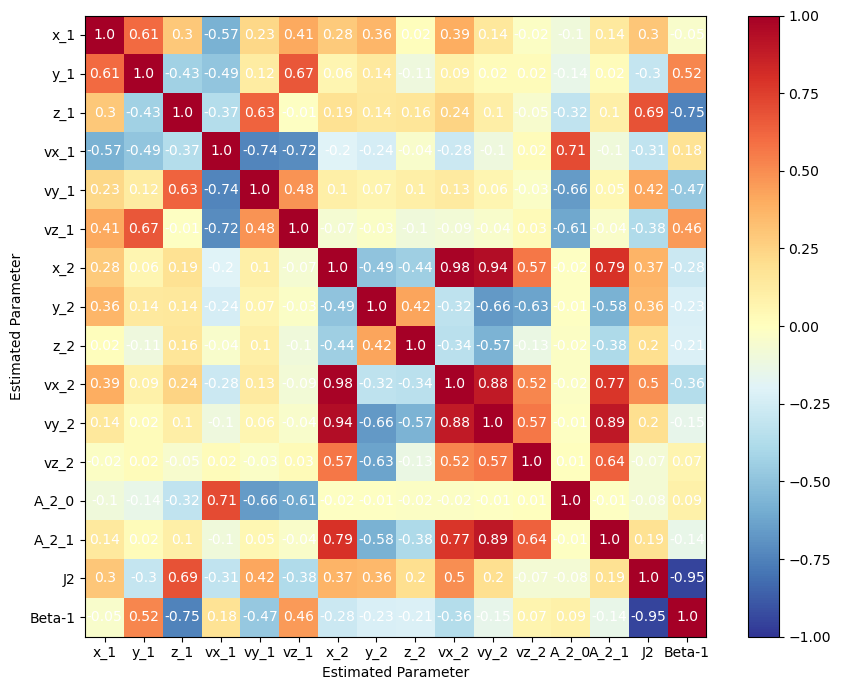

In [257]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [258]:
print(len(correlations))
print(correlations.size)
# print(correlations[-1])
print(covariance_output.formal_errors)
print(covariance_output.design_matrix_consider_parameters)
# print(covariance_output.weighted_design_matrix)

16
256
[3.21420379e+04 4.14698017e+04 4.42939480e+04 2.33168177e-03
 2.32838936e-03 2.25249174e-03 3.45239577e+04 1.32040060e+04
 1.18413293e+04 7.45428886e-03 6.00998236e-03 2.29622823e-03
 5.09193031e-14 7.40321018e-14 1.50085469e-01 8.71897196e-06]
[]


In [51]:
1 / ((0.1 / (3600))**2)

1295999999.9999998

### Manually adding stellar occultations